## Семестровая работа
#### Вариант 5

№1 Задача регрессии (20 баллов)
Возьмите набор данных согласно своему варианту
(https://cloud.mail.ru/public/AQp5/X3obvSZRo). Датасет представляет собой набор
признаков, признак в последнем столбце является целевым (его надо прогнозировать).

In [133]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения

In [45]:
df = pd.read_csv('dataset_var5.csv', delimiter=';')
df

,1,2,3,4,5,6,7,8,Unnamed: 8
0,-1.285471,-0.082709,0.677226,-1.593587,-0.076688,-0.461126,NaN,-57.929267,NaN
1,0.887142,-0.942467,0.538913,-0.437380,-0.126705,0.211382,0.264608,19.240553,NaN
2,1.438531,0.399838,0.118956,-1.513491,2.022652,-0.175398,NaN,-111.526132,NaN
3,1.245329,1.224764,-1.078584,0.963197,0.789414,-1.022447,-1.648925,-28.604144,NaN
4,-0.740921,0.065722,1.815378,-0.374732,0.058958,-1.098040,NaN,151.220905,NaN
...,...,...,...,...,...,...,...,...,...
95,-0.768383,0.186521,2.527073,-1.611165,-0.271732,1.823238,NaN,120.632158,NaN
96,-0.645783,0.935301,-0.483231,-1.242600,-1.308971,-0.222731,NaN,-147.989655,NaN
97,-0.867497,-0.561476,1.818550,0.304557,-0.468108,-0.261695,0.379584,209.640634,NaN
98,0.868606,-0.257774,-2.618762,0.948042,0.037355,0.450220,NaN,-180.181637,NaN


Выведем информацию о датасете

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   1           95 non-null     float64
 1   2           100 non-null    float64
 2   3           100 non-null    float64
 3   4           100 non-null    float64
 4   5           100 non-null    float64
 5   6           100 non-null    float64
 6   7           30 non-null     float64
 7   8           100 non-null    float64
 8   Unnamed: 8  0 non-null      float64
dtypes: float64(9)
memory usage: 7.2 KB


Проверим количество NaN элементов в каждом столбце

In [47]:
df.isna().sum()

1               5
2               0
3               0
4               0
5               0
6               0
7              70
8               0
Unnamed: 8    100
dtype: int64

В 7 столбце 70 NaN значений, его можно удалить целиком, а в 1 столбце удалить только строки

Вообще говоря, если количество отсутствующих данных для
определенного признака достигает более 15%, то этот признак следует удалить

In [48]:
df = df.drop(columns=['7', 'Unnamed: 8'])
df

,1,2,3,4,5,6,8
0,-1.285471,-0.082709,0.677226,-1.593587,-0.076688,-0.461126,-57.929267
1,0.887142,-0.942467,0.538913,-0.437380,-0.126705,0.211382,19.240553
2,1.438531,0.399838,0.118956,-1.513491,2.022652,-0.175398,-111.526132
3,1.245329,1.224764,-1.078584,0.963197,0.789414,-1.022447,-28.604144
4,-0.740921,0.065722,1.815378,-0.374732,0.058958,-1.098040,151.220905
...,...,...,...,...,...,...,...
95,-0.768383,0.186521,2.527073,-1.611165,-0.271732,1.823238,120.632158
96,-0.645783,0.935301,-0.483231,-1.242600,-1.308971,-0.222731,-147.989655
97,-0.867497,-0.561476,1.818550,0.304557,-0.468108,-0.261695,209.640634
98,0.868606,-0.257774,-2.618762,0.948042,0.037355,0.450220,-180.181637


In [49]:
df = df.dropna(axis=0)
df

,1,2,3,4,5,6,8
0,-1.285471,-0.082709,0.677226,-1.593587,-0.076688,-0.461126,-57.929267
1,0.887142,-0.942467,0.538913,-0.437380,-0.126705,0.211382,19.240553
2,1.438531,0.399838,0.118956,-1.513491,2.022652,-0.175398,-111.526132
3,1.245329,1.224764,-1.078584,0.963197,0.789414,-1.022447,-28.604144
4,-0.740921,0.065722,1.815378,-0.374732,0.058958,-1.098040,151.220905
...,...,...,...,...,...,...,...
95,-0.768383,0.186521,2.527073,-1.611165,-0.271732,1.823238,120.632158
96,-0.645783,0.935301,-0.483231,-1.242600,-1.308971,-0.222731,-147.989655
97,-0.867497,-0.561476,1.818550,0.304557,-0.468108,-0.261695,209.640634
98,0.868606,-0.257774,-2.618762,0.948042,0.037355,0.450220,-180.181637


2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой.

In [50]:
df.describe()

,1,2,3,4,5,6,8
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,0.076029,-0.109591,0.304696,0.047764,-0.107540,-0.137915,19.450817
std,1.070353,0.983209,1.468232,1.007875,1.040149,0.945813,128.375640
min,-3.568341,-2.790651,-2.619051,-2.107509,-2.694094,-2.250109,-283.821674
25%,-0.693352,-0.654590,-0.488451,-0.632711,-0.700775,-0.826841,-68.887374
50%,0.196325,-0.082709,0.231128,0.126371,-0.098953,-0.171084,28.409068
75%,0.874419,0.413168,0.952652,0.667134,0.568378,0.423728,105.226428
max,2.567481,2.028566,7.493179,2.515212,2.555169,2.705192,362.998775


<Axes: xlabel='8', ylabel='Count'>

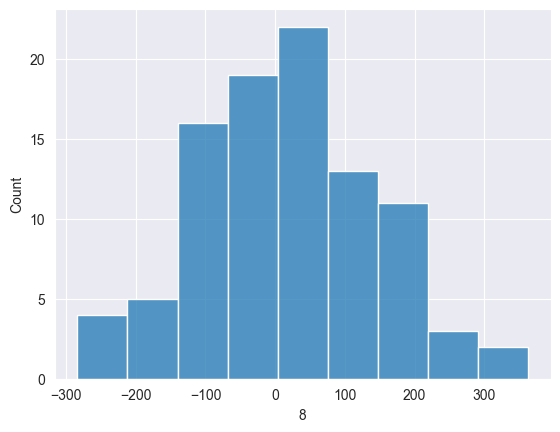

In [51]:
sns.histplot(df['8'])

 Боксплоты не показывают форму распределения, но они могут
дать нам лучшее представление о центре и распространении распределения, а также о любых возможных выбросах, которые могут существовать

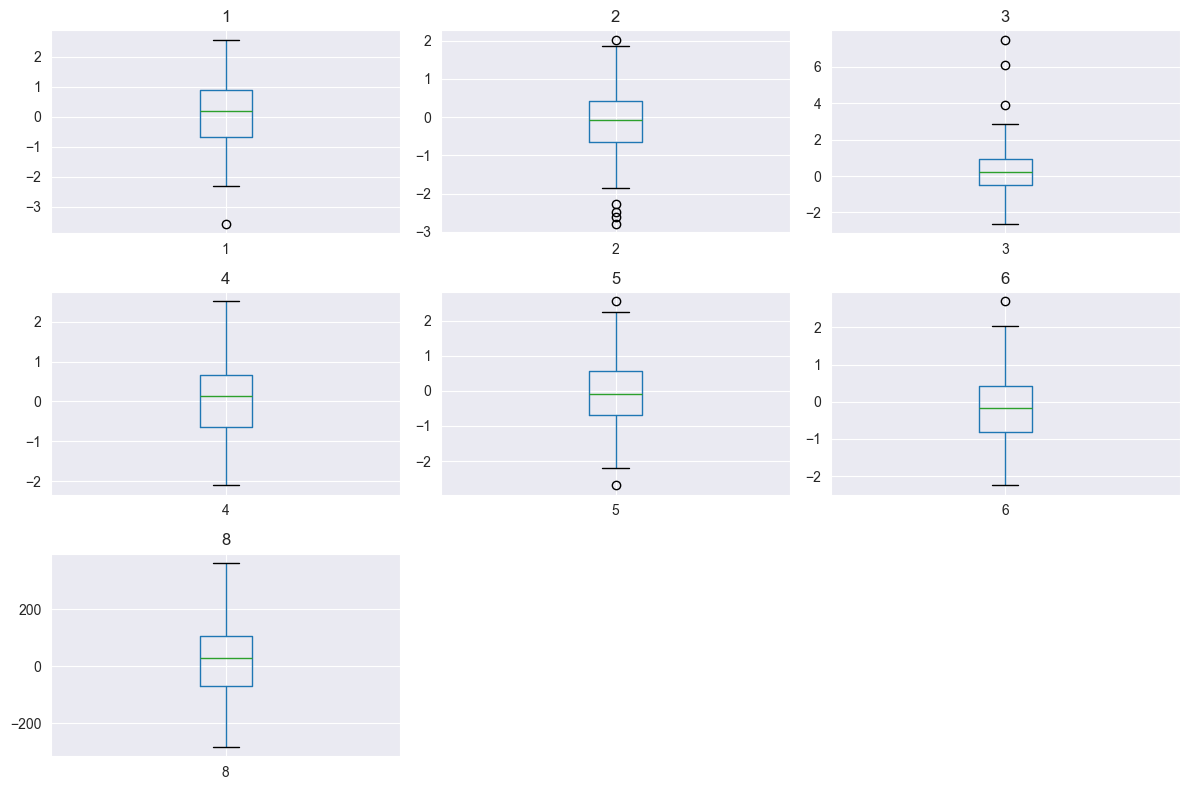

In [52]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

df.boxplot(column='1', ax=axes[0, 0])
axes[0, 0].set_title('1')

df.boxplot(column='2', ax=axes[0, 1])
axes[0, 1].set_title('2')

df.boxplot(column='3', ax=axes[0, 2])
axes[0, 2].set_title('3')

df.boxplot(column='4', ax=axes[1, 0])
axes[1, 0].set_title('4')

df.boxplot(column='5', ax=axes[1, 1])
axes[1, 1].set_title('5')

df.boxplot(column='6', ax=axes[1, 2])
axes[1, 2].set_title('6')

df.boxplot(column='8', ax=axes[2, 0])
axes[2, 0].set_title('8')

fig.delaxes(axes[2, 1])
fig.delaxes(axes[2, 2])

plt.tight_layout()
plt.show()


С помощью мера разброса данных IQR очистим датасет от выбросов

In [53]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
#
# print("Размер до очистки:", df.shape)
# print("Размер после очистки:", df_clean.shape)

any(axis=1) означает: если хотя бы в одном столбце есть выброс — строка удаляется

Альтернатива: заменить выбросы, а не удалять

In [54]:
df_clipped = df.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, axis=1)
print("Размер после очистки:", df_clipped.shape)


Размер после очистки: (95, 7)


In [55]:
df_clipped

,1,2,3,4,5,6,8
0,-1.285471,-0.082709,0.677226,-1.593587,-0.076688,-0.461126,-57.929267
1,0.887142,-0.942467,0.538913,-0.437380,-0.126705,0.211382,19.240553
2,1.438531,0.399838,0.118956,-1.513491,2.022652,-0.175398,-111.526132
3,1.245329,1.224764,-1.078584,0.963197,0.789414,-1.022447,-28.604144
4,-0.740921,0.065722,1.815378,-0.374732,0.058958,-1.098040,151.220905
...,...,...,...,...,...,...,...
95,-0.768383,0.186521,2.527073,-1.611165,-0.271732,1.823238,120.632158
96,-0.645783,0.935301,-0.483231,-1.242600,-1.308971,-0.222731,-147.989655
97,-0.867497,-0.561476,1.818550,0.304557,-0.468108,-0.261695,209.640634
98,0.868606,-0.257774,-2.618762,0.948042,0.037355,0.450220,-180.181637


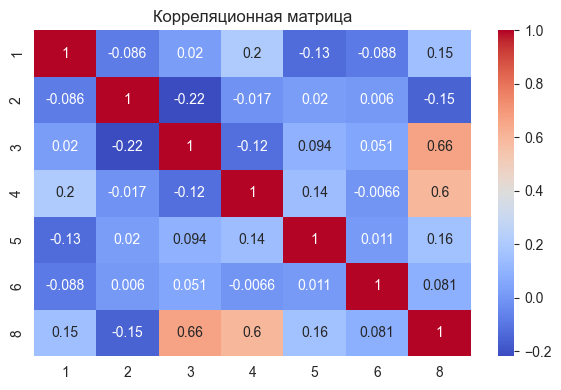

In [56]:
plt.figure(figsize=(6, 4))
correlation_matrix = df_clipped.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

Признак 6 имеет крайне слабую корреляцию с целевым признаком (|r| < 0.1), поэтому был исключён из модели как неинформативный.

In [57]:
df_clipped = df_clipped.drop(columns='6')
df_clipped

,1,2,3,4,5,8
0,-1.285471,-0.082709,0.677226,-1.593587,-0.076688,-57.929267
1,0.887142,-0.942467,0.538913,-0.437380,-0.126705,19.240553
2,1.438531,0.399838,0.118956,-1.513491,2.022652,-111.526132
3,1.245329,1.224764,-1.078584,0.963197,0.789414,-28.604144
4,-0.740921,0.065722,1.815378,-0.374732,0.058958,151.220905
...,...,...,...,...,...,...
95,-0.768383,0.186521,2.527073,-1.611165,-0.271732,120.632158
96,-0.645783,0.935301,-0.483231,-1.242600,-1.308971,-147.989655
97,-0.867497,-0.561476,1.818550,0.304557,-0.468108,209.640634
98,0.868606,-0.257774,-2.618762,0.948042,0.037355,-180.181637


3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%).

Нормализация данных датасета — это процедура предобработки, при которой значения признаков в наборе данных приводятся к некоторому заданному диапазону

In [58]:
X = df_clipped.drop(columns='8')
y = df_clipped['8']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

4. Для предсказания целевого признака постройте следующие модели, используя
библиотеку sklearn:


a. Линейная регрессия LinearRegression()


In [59]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"MSE (обучающая выборка): {mse_train:.4f}")
print(f"R² (обучающая выборка): {r2_train:.4f}")
print(f"MSE (тестовая выборка): {mse_test:.4f}")
print(f"R² (тестовая выборка): {r2_test:.4f}")

MSE (обучающая выборка): 1582.3635
R² (обучающая выборка): 0.8977
MSE (тестовая выборка): 1629.1293
R² (тестовая выборка): 0.9035


b. Случайный лес RandomForestRegressor()

In [60]:
rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)

y_pred_train = rfr.predict(X_train)
y_pred_test = rfr.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"MSE (обучающая выборка): {mse_train:.4f}")
print(f"R² (обучающая выборка): {r2_train:.4f}")
print(f"MSE (тестовая выборка): {mse_test:.4f}")
print(f"R² (тестовая выборка): {r2_test:.4f}")

MSE (обучающая выборка): 434.2409
R² (обучающая выборка): 0.9719
MSE (тестовая выборка): 3869.2411
R² (тестовая выборка): 0.7709


c. Метод ближайших соседей KNeighborsRegressor()

In [61]:
# Определяем диапазон значений k для проверки
param_grid = {'n_neighbors': np.arange(1, 20)}

knn = KNeighborsRegressor()
# Создаем объект GridSearchCV для поиска оптимального k
grid_search = GridSearchCV(knn, param_grid, cv=5)

# Обучаем на тренировочных данных
grid_search.fit(X_train, y_train)

# Выводим лучшее значение k
print(f"Оптимальное значение k: {grid_search.best_params_['n_neighbors']}")
print(f"Лучшая точность при кросс-валидации: {grid_search.best_score_:.4f}")

Оптимальное значение k: 3
Лучшая точность при кросс-валидации: 0.6684


In [62]:
neigh = KNeighborsRegressor(n_neighbors=3)
neigh.fit(X_train, y_train)

y_pred_train = neigh.predict(X_train)
y_pred_test = neigh.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"MSE (обучающая выборка): {mse_train:.4f}")
print(f"R² (обучающая выборка): {r2_train:.4f}")
print(f"MSE (тестовая выборка): {mse_test:.4f}")
print(f"R² (тестовая выборка): {r2_test:.4f}")

MSE (обучающая выборка): 2749.2322
R² (обучающая выборка): 0.8222
MSE (тестовая выборка): 4555.9464
R² (тестовая выборка): 0.7302


d. Метод опорных векторов SVR()

In [63]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1]
}

svr = SVR(kernel='linear')

grid = GridSearchCV(
    svr,
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший R² (CV):", grid.best_score_)


Лучшие параметры: {'C': 10, 'epsilon': 1}
Лучший R² (CV): 0.7654595636915146


In [64]:
svr = SVR(kernel='linear', C=10, epsilon=1)
svr.fit(X_train, y_train)

y_pred_train = svr.predict(X_train)
y_pred_test = svr.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"MSE (обучающая выборка): {mse_train:.4f}")
print(f"R² (обучающая выборка): {r2_train:.4f}")
print(f"MSE (тестовая выборка): {mse_test:.4f}")
print(f"R² (тестовая выборка): {r2_test:.4f}")

MSE (обучающая выборка): 2344.4610
R² (обучающая выборка): 0.8484
MSE (тестовая выборка): 1359.6793
R² (тестовая выборка): 0.9195


5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.

6. Оцените качество работы моделей. Выведите для каждой модели ее score().
Напишите какая модель дала наилучший результат. Выведите ее значение
feature_importances

* На тренировочных данных лучший результат дала модель RandomForestRegressor()(случайного леса)
* На тестовых данных - метод опорных векторов SVR()

In [65]:
print(rfr.feature_importances_)

[0.01728841 0.01865482 0.42965856 0.5143332  0.02006502]


В случае модели опорных векторов, модель имеет веса coef_.
* знак это направление влияния
* модуль это сила влияния

In [66]:
print(svr.coef_)

[[ -0.62656645  -0.92366747 104.62386066  77.69745453  -0.34078765]]


№2 Задача классификации (20 баллов)

Возьмите набор данных согласно своему варианту
(https://cloud.mail.ru/public/MWZh/DQkbAHKmi). Датасет представляет собой набор
признаков, в последнем столбце указан класс объекта

1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения

In [140]:
df_class = pd.read_csv('dataset_var5_class.csv', delimiter=';')
df_class

,1,2,3,4,5,6,7,8
0,0.857794,1.191141,-2.501944,-0.072310,0.927593,-2.501944,2.062941,1
1,0.974847,0.245309,0.588575,-1.816516,0.754855,0.588575,2.070349,2
2,0.965456,-0.211132,0.891785,-1.046728,-0.564424,0.891785,-0.018404,2
3,0.063394,0.188988,1.323047,-0.488879,0.588116,1.323047,1.652926,2
4,0.023869,-1.689940,-0.985888,-0.581443,1.084856,-0.985888,1.410528,1
...,...,...,...,...,...,...,...,...
95,0.330809,0.496897,1.191611,-2.132284,0.168255,1.191611,-0.183433,1
96,1.180839,-0.943616,1.055178,-1.697694,-0.920702,1.055178,-0.866714,0
97,1.990013,-0.053940,-0.797827,-1.646157,-0.532564,-0.797827,0.384690,1
98,1.761664,-0.880580,-3.098523,0.601187,0.506036,-3.098523,2.858153,1


In [141]:
df_class.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       95 non-null     float64
 1   2       100 non-null    float64
 2   3       100 non-null    float64
 3   4       95 non-null     float64
 4   5       100 non-null    float64
 5   6       100 non-null    float64
 6   7       100 non-null    float64
 7   8       100 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 6.4 KB


In [142]:
df_class.isna().sum()

1    5
2    0
3    0
4    5
5    0
6    0
7    0
8    0
dtype: int64

In [143]:
df_class = df_class.dropna(axis=0)
df_class

,1,2,3,4,5,6,7,8
0,0.857794,1.191141,-2.501944,-0.072310,0.927593,-2.501944,2.062941,1
1,0.974847,0.245309,0.588575,-1.816516,0.754855,0.588575,2.070349,2
2,0.965456,-0.211132,0.891785,-1.046728,-0.564424,0.891785,-0.018404,2
3,0.063394,0.188988,1.323047,-0.488879,0.588116,1.323047,1.652926,2
4,0.023869,-1.689940,-0.985888,-0.581443,1.084856,-0.985888,1.410528,1
...,...,...,...,...,...,...,...,...
94,1.580120,-0.396851,0.871551,-1.245822,-0.487639,0.871551,0.979329,2
95,0.330809,0.496897,1.191611,-2.132284,0.168255,1.191611,-0.183433,1
96,1.180839,-0.943616,1.055178,-1.697694,-0.920702,1.055178,-0.866714,0
97,1.990013,-0.053940,-0.797827,-1.646157,-0.532564,-0.797827,0.384690,1


2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой

In [144]:
df_class.describe()

,1,2,3,4,5,6,7,8
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,1.395025,0.092089,0.274398,-0.904753,-0.217213,0.274398,0.545203,1.044444
std,3.391563,0.950400,1.542133,0.892225,0.860763,1.542133,1.337910,0.806032
min,-6.126172,-1.822825,-4.098430,-2.955793,-2.241120,-4.098430,-2.808024,0.000000
25%,0.335916,-0.640638,-0.571980,-1.510644,-0.866994,-0.571980,-0.228935,0.000000
50%,1.102547,0.085388,0.752727,-1.118258,-0.233855,0.752727,0.464788,1.000000
75%,1.594318,0.704034,1.181329,-0.254628,0.408715,1.181329,1.694591,2.000000
max,29.221409,2.130651,3.516411,1.362547,1.907537,3.516411,3.225826,2.000000


<Axes: xlabel='8', ylabel='Count'>

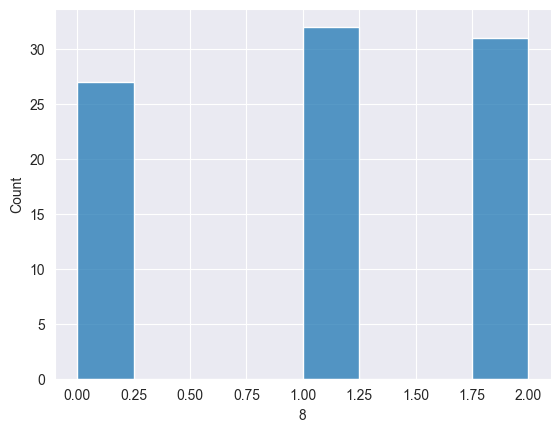

In [145]:
sns.histplot(df_class['8'])

Выводим боксплоты по каждому столбцу, чтобы оценить выбросы

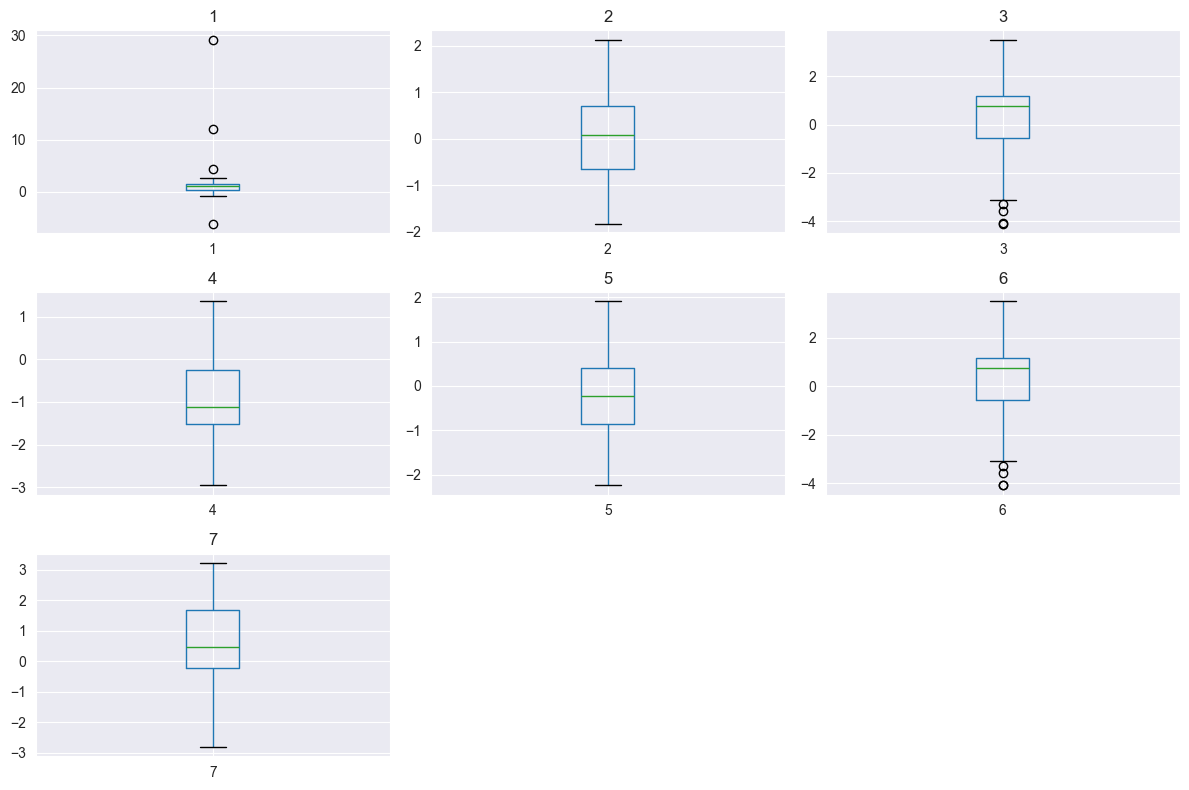

In [146]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

df_class.boxplot(column='1', ax=axes[0, 0])
axes[0, 0].set_title('1')

df_class.boxplot(column='2', ax=axes[0, 1])
axes[0, 1].set_title('2')

df_class.boxplot(column='3', ax=axes[0, 2])
axes[0, 2].set_title('3')

df_class.boxplot(column='4', ax=axes[1, 0])
axes[1, 0].set_title('4')

df_class.boxplot(column='5', ax=axes[1, 1])
axes[1, 1].set_title('5')

df_class.boxplot(column='6', ax=axes[1, 2])
axes[1, 2].set_title('6')

df_class.boxplot(column='7', ax=axes[2, 0])
axes[2, 0].set_title('7')


fig.delaxes(axes[2, 1])
fig.delaxes(axes[2, 2])

plt.tight_layout()
plt.show()


In [147]:
Q1 = df_class.quantile(0.25)
Q3 = df_class.quantile(0.75)
IQR = Q3 - Q1
df_class_clipped = df_class.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, axis=1)
print("Размер после преобразования:", df_class_clipped.shape)


Размер после преобразования: (90, 8)


In [148]:
df_class_clipped

,1,2,3,4,5,6,7,8
0,0.857794,1.191141,-2.501944,-0.072310,0.927593,-2.501944,2.062941,1
1,0.974847,0.245309,0.588575,-1.816516,0.754855,0.588575,2.070349,2
2,0.965456,-0.211132,0.891785,-1.046728,-0.564424,0.891785,-0.018404,2
3,0.063394,0.188988,1.323047,-0.488879,0.588116,1.323047,1.652926,2
4,0.023869,-1.689940,-0.985888,-0.581443,1.084856,-0.985888,1.410528,1
...,...,...,...,...,...,...,...,...
94,1.580120,-0.396851,0.871551,-1.245822,-0.487639,0.871551,0.979329,2
95,0.330809,0.496897,1.191611,-2.132284,0.168255,1.191611,-0.183433,1
96,1.180839,-0.943616,1.055178,-1.697694,-0.920702,1.055178,-0.866714,0
97,1.990013,-0.053940,-0.797827,-1.646157,-0.532564,-0.797827,0.384690,1


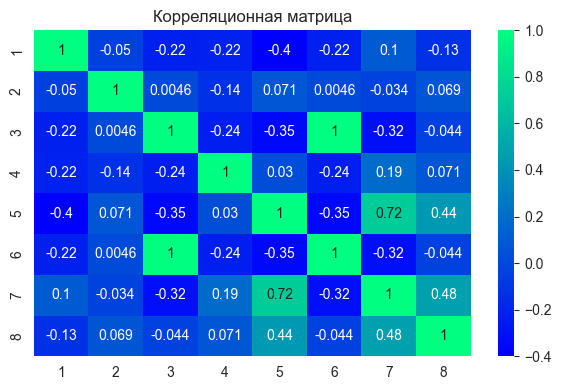

In [166]:
plt.figure(figsize=(6, 4))
correlation_matrix = df_class_clipped.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='winter')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

* 3 столбец имеет корреляция 1 с 6-ым столбцом, это значит они совпадают и 6 столбец можно удалить

In [150]:
df = df_class_clipped.drop(columns=['6'])
df

,1,2,3,4,5,7,8
0,0.857794,1.191141,-2.501944,-0.072310,0.927593,2.062941,1
1,0.974847,0.245309,0.588575,-1.816516,0.754855,2.070349,2
2,0.965456,-0.211132,0.891785,-1.046728,-0.564424,-0.018404,2
3,0.063394,0.188988,1.323047,-0.488879,0.588116,1.652926,2
4,0.023869,-1.689940,-0.985888,-0.581443,1.084856,1.410528,1
...,...,...,...,...,...,...,...
94,1.580120,-0.396851,0.871551,-1.245822,-0.487639,0.979329,2
95,0.330809,0.496897,1.191611,-2.132284,0.168255,-0.183433,1
96,1.180839,-0.943616,1.055178,-1.697694,-0.920702,-0.866714,0
97,1.990013,-0.053940,-0.797827,-1.646157,-0.532564,0.384690,1


3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%)

In [151]:
X = df.drop(columns='8')
y = df['8']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

4. Для предсказания класса постройте две модели, используя библиотеку sklearn:

a. Случайный лес RandomForestClassifier()

In [155]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Random Forest Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.58      1.00      0.74         7
           1       0.94      0.88      0.91        17
           2       1.00      0.67      0.80        12

    accuracy                           0.83        36
   macro avg       0.84      0.85      0.82        36
weighted avg       0.89      0.83      0.84        36

[[ 7  0  0]
 [ 2 15  0]
 [ 3  1  8]]


* Если мы рассмотрим долю правильно предсказанных положительных объектов среди всех объектов, предсказанных положительным классом, то мы получим метрику, которая называется точностью (precision)
* Если же мы рассмотрим долю правильно найденных положительных объектов среди всех объектов положительного класса, то мы получим метрику, которая называется полнотой (recall)
* Как мы уже отмечали ранее, модели очень удобно сравнивать, когда их качество выражено одним числом. В случае пары Precision-Recall существует популярный способ скомпоновать их в одну метрику - взять их среднее гармоническое. Данный показатель эффективности исторически носит название F1-меры (F1-measure).

Попробуем с помощью GridSearchCV подобрать наилучшие параметры для случайного леса

In [156]:
param_grid = {
    'n_estimators': [100, 200, 300],          # количество деревьев
    'max_depth': [None, 10, 20, 30],          # глубина
    'min_samples_split': [2, 5, 10],          # минимум для сплита
    'min_samples_leaf': [1, 2, 4],            # минимум объектов в листе
    'max_features': ['sqrt', 'log2', None],   # выбор признаков
    'bootstrap': [True, False]                # бутстрап выборки
}

grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

best_clf = grid_search.best_estimator_

y_pred = best_clf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

{'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Random Forest Accuracy: 0.8611111111111112
              precision    recall  f1-score   support

           0       0.64      1.00      0.78         7
           1       0.94      0.88      0.91        17
           2       1.00      0.75      0.86        12

    accuracy                           0.86        36
   macro avg       0.86      0.88      0.85        36
weighted avg       0.90      0.86      0.87        36

[[ 7  0  0]
 [ 2 15  0]
 [ 2  1  9]]


b. Метод ближайших соседей KNeighborsClassifier()

In [159]:
neigh = KNeighborsClassifier()
neigh.fit(X_train, y_train)

y_pred = neigh.predict(X_test)

print("KNeighbors Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

KNeighbors Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

           0       0.50      0.86      0.63         7
           1       0.92      0.71      0.80        17
           2       0.73      0.67      0.70        12

    accuracy                           0.72        36
   macro avg       0.72      0.74      0.71        36
weighted avg       0.78      0.72      0.73        36

[[ 6  0  1]
 [ 3 12  2]
 [ 3  1  8]]


Попробуем подобрать оптимальное количество соседей

In [163]:
param_grid_knn = {
    'n_neighbors': range(1, 20),
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()


grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))


KNN Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

           0       0.56      0.71      0.62         7
           1       0.92      0.71      0.80        17
           2       0.64      0.75      0.69        12

    accuracy                           0.72        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.76      0.72      0.73        36

[[ 5  0  2]
 [ 2 12  3]
 [ 2  1  9]]


5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.
6. Оцените качество работы моделей. Выведите метрики модели. Напишите какая
модель дала наилучший результат.

Наилучший результат дала модель RandomForestClassifier() с подбором параметров {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Random Forest Accuracy: 0.8611111111111112